# x26 GAT for embedding

In this experiment, we will try using Graph Attention Layers (GATv2) in our embedding network instead of the GCN that we had been using.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)
# Choose device (cuda if available, else cpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

2.9.0+cu128
Selected device: cuda


## Load Data from Disk

In [18]:
## Load pre-generated data
import pathlib

# Load the pre-generated data from disk
# To generate new data, run: python generate_data.py
data_path = pathlib.Path('data/data-4.pt')
print(f"Loading data from {data_path}")
data = torch.load(data_path, weights_only=False)

# Extract the data
graph_a_list = data['graph_a_list']
graph_b_list = data['graph_b_list']
labels_translations = data['labels_translations']
labels_quat_xyzw = data['labels_quat_xyzw']

# Print metadata
print(f"Loaded {len(graph_a_list)} samples")
print(f"Metadata: {data['metadata']}")

Loading data from data\data-4.pt
Loaded 1000 samples
Metadata: {'num_samples': 1000, 'subset_size': 15, 'include_image_features': True, 'translation_range': (-1.0, 1.0), 'random_seed': 42, 'model_path': 'output\\01_nerf\\02_lego_large\\1762043798762\\0', 'image_dir': 'data\\01_nerf\\02_lego_large'}


## Construct Dataset

In [19]:
from utils.loaders.dataset import SfmPairDataset

# Create the Dataset
dataset = SfmPairDataset(graph_a_list, graph_b_list, labels_translations, labels_quat_xyzw)
dataset

SfmPairDataset(1000)

In [20]:
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

# Split our dataset based on 80-20 training-validation split
dataset_size = len(dataset)
train_size = int(dataset_size * 0.8)
val_size = dataset_size - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Training Loop

In [22]:
from models.models import SiameseGAT_v7
import random
from models import SiameseGCN_v3, SiameseGCN_v4, SiameseGCN_v5, SiameseGCN_v6
import roma
import numpy as np
from tqdm import tqdm
from hydra import compose, initialize
from omegaconf import OmegaConf
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from utils.loss import compute_combined_loss, compute_angular_error

# Load the config
with initialize(version_base=None, config_path="conf"):
    cfg = compose(
        # Load config
        config_name="config",
        # Override params programmatically
        overrides=[
            "model.embedding_size=64",
            "training.batch_size=32",
            "training.num_epochs=500",
            "training.lambda_frobenius=0.01",
            "training.lambda_translation=1.0",
            "training.lr=0.01"]
    )
    # Inspect what config was loaded
    print(OmegaConf.to_yaml(cfg))

# And we create a distinct DataLoader for each dataset train and val
train_loader = DataLoader(train_dataset, cfg.training.batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, cfg.training.batch_size, shuffle=False)

# View results by running in the terminal:
# tensorboard --logdir=runs
timestamp_str = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter(f'runs/x26_GAT_emb{cfg.model.embedding_size}/{timestamp_str}')

# Log config
writer.add_text("config", OmegaConf.to_yaml(cfg))

# Set seeds for reproducibility
torch.manual_seed(43)
random.seed(43)

# Define model
num_node_features = dataset.g_list_1[0].num_features
model = SiameseGAT_v7(num_node_features, graph_embedding_dim=cfg.model.embedding_size)
model.to(device)

# Log the model
writer.add_text("model", str(model))

# optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
# optimizer = torch.optim.SGD(model.parameters(), lr=cfg.training.lr, momentum=0.9)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.training.lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)
criterion_translation = torch.nn.MSELoss()
criterion_rotation = torch.nn.L1Loss()

# Keep track of loss for logging
epoch_losses_train = []
epoch_losses_val = np.full(cfg.training.num_epochs, np.nan)  # one slot per epoch. makes plotting easier
with tqdm(range(cfg.training.num_epochs),desc=f"Training progress") as pbar:
    for epoch in pbar:
        model.train()
        train_loss_all = 0.0
        train_loss_translation = 0.0
        train_loss_rotation = 0.0
        train_angular_error = 0.0
        train_frobenius_norm = 0.0
        train_translation_error = 0.0
        for batch in train_loader:
            # Move data to the GPU
            graph_a_batch         = batch[0].to(device)
            graph_b_batch         = batch[1].to(device)
            labels_translations   = batch[2].to(device)
            labels_quat_xyzw      = batch[3].to(device)
            optimizer.zero_grad()
            pred_translation, pred_rotation_raw = model(graph_a_batch, graph_b_batch)
            # "Normalize" the predicted matrix so that it is a valid SO(3) rotation matrix
            pred_rotation = roma.special_procrustes(pred_rotation_raw)

            # Calculate Frobenius norm between pred_rotation_raw and pred_rotation
            # This measures how far the raw prediction is from the SO(3) manifold
            frobenius_norm = torch.norm(pred_rotation_raw - pred_rotation, p='fro', dim=(-2, -1)).mean()

            # Calculate losses using the helper function
            loss, loss_trans, loss_rotation = compute_combined_loss(
                pred_translation, pred_rotation, labels_translations, labels_quat_xyzw,
                criterion_translation, criterion_rotation, cfg.training.lambda_translation
            )

            # Add Frobenius norm as regularization term
            lambda_frobenius = cfg.training.lambda_frobenius
            loss = loss + lambda_frobenius * frobenius_norm
            # Calculate angular error
            true_rotmat = roma.unitquat_to_rotmat(labels_quat_xyzw)
            angular_error = compute_angular_error(pred_rotation, true_rotmat)
            train_angular_error += angular_error.mean().item()

            # Calculate translation error (L2 norm)
            translation_error = torch.norm(pred_translation - labels_translations, p=2, dim=-1).mean()
            train_translation_error += translation_error.item()

            # Compute gradient
            loss.backward()
            # update the weights
            optimizer.step()
            train_loss_all += loss.item()
            train_loss_translation += loss_trans.item()
            train_loss_rotation += loss_rotation.item()
            train_frobenius_norm += frobenius_norm.item()
        avg_loss = train_loss_all / len(train_loader)
        avg_loss_translation = train_loss_translation / len(train_loader)
        avg_loss_rotation = train_loss_rotation / len(train_loader)
        avg_angular_error = train_angular_error / len(train_loader)
        avg_frobenius_norm = train_frobenius_norm / len(train_loader)
        avg_translation_error = train_translation_error / len(train_loader)
        writer.add_scalar('loss_all/train', avg_loss, epoch)
        writer.add_scalar('loss_translation/train', avg_loss_translation, epoch)
        writer.add_scalar('loss_rotation/train', avg_loss_rotation, epoch)
        writer.add_scalar('angular_error/train', avg_angular_error, epoch)
        writer.add_scalar('frobenius_norm/train', avg_frobenius_norm, epoch)
        writer.add_scalar('translation_error/train', avg_translation_error, epoch)
        epoch_losses_train.append(avg_loss)
        pbar.set_postfix({'loss': f'{avg_loss:.4f}', 'loss_trans': f'{avg_loss_translation:.4f}', 'loss_rot:': f'{avg_loss_rotation:.4f}', 'ang_err': f'{avg_angular_error:.2f}°', 'frob': f'{avg_frobenius_norm:.4f}' })
        # learning rate decay
        if scheduler is not None:
            scheduler.step()

        # Validation
        if epoch % 10 == 0:
            model.eval()
            val_loss = 0.0
            val_loss_translation = 0.0
            val_loss_rotation = 0.0
            val_angular_error = 0.0
            val_frobenius_norm = 0.0
            val_translation_error = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    graph_a_batch = batch[0].to(device)
                    graph_b_batch = batch[1].to(device)
                    labels_translations   = batch[2].to(device)
                    labels_quat_xyzw   = batch[3].to(device)
                    pred_translation, pred_rotation_raw = model(graph_a_batch, graph_b_batch)
                    # "Normalize" the predicted matrix so that it is a valid SO(3) rotation matrix
                    pred_rotation = roma.special_procrustes(pred_rotation_raw)

                    # Calculate Frobenius norm between pred_rotation_raw and pred_rotation
                    frobenius_norm = torch.norm(pred_rotation_raw - pred_rotation, p='fro', dim=(-2, -1)).mean()

                    # Calculate losses using the helper function
                    loss, loss_trans, loss_rotation = compute_combined_loss(
                        pred_translation, pred_rotation, labels_translations, labels_quat_xyzw,
                        criterion_translation, criterion_rotation, cfg.training.lambda_translation
                    )

                    # Add Frobenius norm as regularization term
                    lambda_frobenius = cfg.training.lambda_frobenius  # Weight for the regularization term
                    loss = loss + lambda_frobenius * frobenius_norm

                    # Calculate angular error
                    true_rotmat = roma.unitquat_to_rotmat(labels_quat_xyzw)
                    angular_error = compute_angular_error(pred_rotation, true_rotmat)
                    val_angular_error += angular_error.mean().item()

                    # Calculate translation error (L2 norm)
                    translation_error = torch.norm(pred_translation - labels_translations, p=2, dim=-1).mean()
                    val_translation_error += translation_error.item()

                    val_loss += loss.item()
                    val_loss_translation += loss_trans.item()
                    val_loss_rotation += loss_rotation.item()
                    val_frobenius_norm += frobenius_norm.item()
                avg_val_loss = val_loss / len(val_loader)
                avg_val_loss_translation = val_loss_translation / len(val_loader)
                avg_val_loss_rotation = val_loss_rotation / len(val_loader)
                avg_val_angular_error = val_angular_error / len(val_loader)
                avg_val_frobenius_norm = val_frobenius_norm / len(val_loader)
                avg_val_translation_error = val_translation_error / len(val_loader)
                epoch_losses_val[epoch] = avg_val_loss
                writer.add_scalar('loss_all/val', avg_val_loss, epoch)
                writer.add_scalar('loss_translation/val', avg_val_loss_translation, epoch)
                writer.add_scalar('loss_rotation/val', avg_val_loss_rotation, epoch)
                writer.add_scalar('angular_error/val', avg_val_angular_error, epoch)
                writer.add_scalar('frobenius_norm/val', avg_val_frobenius_norm, epoch)
                writer.add_scalar('translation_error/val', avg_val_translation_error, epoch)

model:
  embedding_size: 64
training:
  num_epochs: 500
  batch_size: 32
  lr: 0.01
  lambda_translation: 1.0
  lambda_frobenius: 0.01



Training progress: 100%|██████████| 500/500 [07:36<00:00,  1.09it/s, loss=0.2790, loss_trans=0.1131, loss_rot:=0.1494, ang_err=23.05°, frob=1.6631]


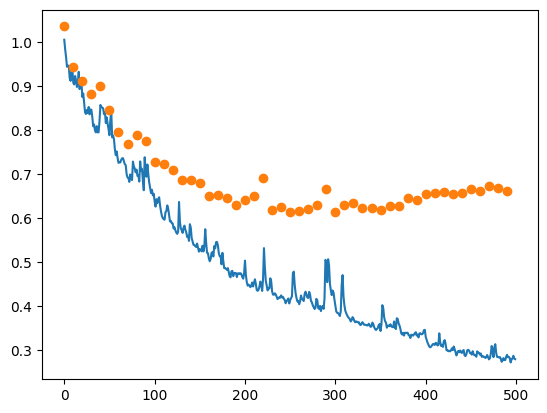

In [23]:
# Plot the results!
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epoch_losses_train)
plt.plot(epoch_losses_val, marker='o')
plt.show()

# Calculate Angular Error

In [24]:
model.eval()
angular_errors = []

with torch.no_grad():
    for batch in val_loader:
        graph_a_batch = batch[0].to(device)
        graph_b_batch = batch[1].to(device)
        labels_quat_xyzw = batch[3].to(device)

        pred_translation, pred_rotation_raw = model(graph_a_batch, graph_b_batch)
        pred_rotation = roma.special_procrustes(pred_rotation_raw)

        # Convert ground truth quaternions to rotation matrices
        true_rotmat = roma.unitquat_to_rotmat(labels_quat_xyzw)

        # Compute angular error
        errors = compute_angular_error(pred_rotation, true_rotmat)
        angular_errors.extend(errors.cpu().numpy())

angular_errors = np.array(angular_errors)
print(f"Mean angular error: {angular_errors.mean():.2f}°")
print(f"Median angular error: {np.median(angular_errors):.2f}°")
print(f"Std angular error: {angular_errors.std():.2f}°")

Mean angular error: 49.11°
Median angular error: 40.44°
Std angular error: 35.30°


# Visualize Prediction

Here we visualize a prediction. This visual is for the training dataset. We notice it looks pretty good! But if we take a look at an example from the validation dataset... we will see that it fails to generalize.

In [25]:
import utils.vis

# Use the new helper function to visualize predictions
# sample = train_dataset[15]
sample = val_dataset[0]
predicted_graph_b, true_graph_b, graph_a, graph_b = utils.vis.visualize_sfm_prediction(model, sample)

# Conclusion

Doesn't seem like GAT does much to improve (as least, in our current simple experimental setup)